In [1]:
!pip install astroquery
!pip install astropy

In [2]:
import matplotlib.pyplot as plt
from astroquery.skyview import SkyView

In [3]:
# Get the Andromeda data (M31) from SDSSg Survey using SkyView (Header Data Unit)
hdu = SkyView.get_images("M31", "SDSSg")[0][0]
hdu

In [4]:
# Get the Metadata using header
M31_header = hdu.header
print(M31_header)

SIMPLE  =                    T / Written by SkyView Thu Mar 19 16:55:32 EDT 2026BITPIX  =                  -32 / 4 byte floating point                          NAXIS   =                    2 / Two dimensional image                          NAXIS1  =                  300 / Width of image                                 NAXIS2  =                  300 / Height of image                                CRVAL1  =              10.6847 / Reference longitude                            CRVAL2  =              41.2688 / Reference latitude                             RADESYS = 'FK5     '           / Coordinate system                              EQUINOX =               2000.0 / Epoch of the equinox                           CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      CRPIX1  =                150.5 / X reference pixel                              CRPIX2  =                150.5 / Y refer

In [5]:
# Get the pixels data from HDU
M31_Pixels = hdu.data
print(M31_Pixels)

[[5.4453125 5.453125  5.4453125 ... 7.4609375 7.515625  7.4140625]
 [5.4375    5.453125  5.421875  ... 7.625     7.4453125 7.4453125]
 [5.4765625 5.359375  5.4609375 ... 7.4375    7.5625    7.46875  ]
 ...
 [7.3984375 7.3984375 7.546875  ... 5.53125   5.671875  5.7578125]
 [7.46875   7.6171875 7.5859375 ... 5.6640625 5.671875  5.5625   ]
 [7.53125   7.5078125 7.5859375 ... 5.53125   5.59375   5.5546875]]


In [6]:
# Check the type - must be numpy array
type(M31_Pixels)

numpy.ndarray

In [7]:
# Check the shape of the array
M31_Pixels.shape

(300, 300)

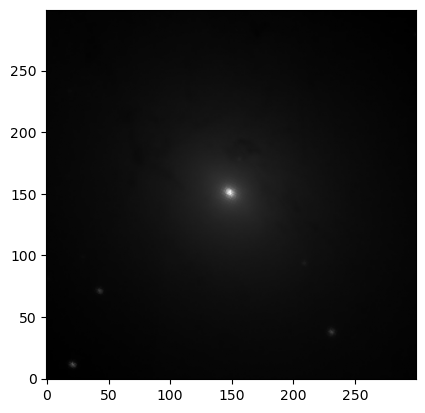

In [8]:
# Plot the image
plt.imshow(M31_Pixels, cmap='gray', origin='lower')

In [9]:
import astropy.units as u

In [10]:
hdu = SkyView.get_images("M31", "DSS2 Blue",
                         pixels=600,
                         radius=150*u.arcmin)[0][0]

In [11]:
M31_DSS2_Blue_Pixels = hdu.data

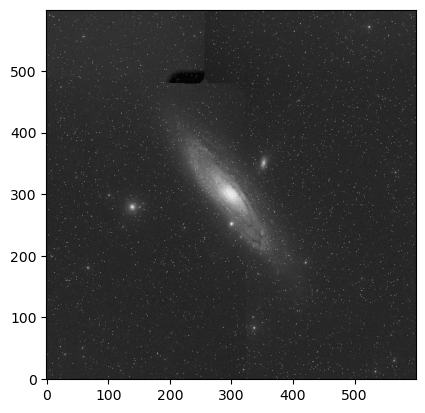

In [12]:
plt.imshow(M31_DSS2_Blue_Pixels, cmap='gray', origin='lower')

In [13]:
# Import fits from io module of astropy
from astropy.io import fits

In [14]:
# Steps to prepare data for FITS file

# 1) Create HDUList() to store different HDUs
hdulist = fits.HDUList()

# 2) Create the PrimaryHDU()
hdu1 = fits.PrimaryHDU()

# 3) Add Pixels data
hdu1.data = M31_Pixels

# 4) Add Meta data
hdu1.header = M31_header

# 5) Append this Primary HDU to the HDU List
hdulist.append(hdu1)

# 6) Generate the FITS data
hdulist.writeto('Dummy_FITS_file.fits', overwrite=True)

In [15]:
# Open the FITS data generated by you!
My_fits = fits.open('./Dummy_FITS_file.fits')

# Starting by checking info
My_fits

In [16]:
# What's inside first index of our FITS data?
My_fits[0]

In [17]:
# Check the header info
My_fits[0].header

SIMPLE  =                    T / Written by SkyView Thu Mar 19 16:55:32 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =              10.6847 / Reference longitude                            
CRVAL2  =              41.2688 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

In [18]:
# Check the pixels using .data
My_fits[0].data

array([[5.4453125, 5.453125 , 5.4453125, ..., 7.4609375, 7.515625 ,
        7.4140625],
       [5.4375   , 5.453125 , 5.421875 , ..., 7.625    , 7.4453125,
        7.4453125],
       [5.4765625, 5.359375 , 5.4609375, ..., 7.4375   , 7.5625   ,
        7.46875  ],
       ...,
       [7.3984375, 7.3984375, 7.546875 , ..., 5.53125  , 5.671875 ,
        5.7578125],
       [7.46875  , 7.6171875, 7.5859375, ..., 5.6640625, 5.671875 ,
        5.5625   ],
       [7.53125  , 7.5078125, 7.5859375, ..., 5.53125  , 5.59375  ,
        5.5546875]], shape=(300, 300), dtype='>f4')

In [19]:
# Store it in a variable
dummy_data_var = My_fits[0].data

In [20]:
# Get the shape
dummy_data_var.shape

(300, 300)

In [21]:
# Get the type of the variable
type(dummy_data_var)

numpy.ndarray

##  Pixel Scaling on M31 Data

In [22]:
# Import necessary libraries to get started with Pixel Scaling
import numpy as np

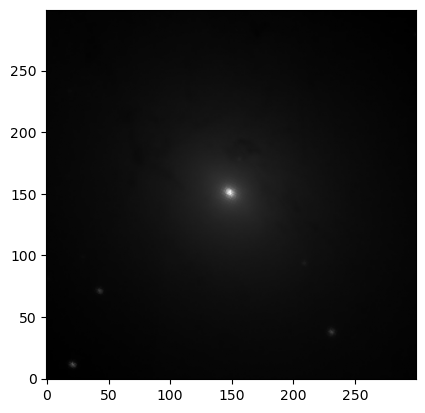

In [23]:
# Visualizing M31_Pixels once again
plt.imshow(M31_Pixels, cmap='gray', origin='lower')

In [24]:
# Printing the value of Pixel at the Center of Andromeda Galaxy
M31_Pixels[151, 151]

np.float32(126.5)

In [25]:
# Check some statistic (min, max, mean, std) of the data using numpy
print('Summary Statistics of M31 Pixels:-')
print(f'Minimum:- {np.min(M31_Pixels)}')
print(f'Maximum:- {np.max(M31_Pixels)}')
print(f'Average:- {np.mean(M31_Pixels)}')
print(f'Std:- {np.std(M31_Pixels)}')

Summary Statistics of M31 Pixels:-
Minimum:- 5.359375
Maximum:- 178.0
Average:- 13.329444885253906
Std:- 6.3922271728515625


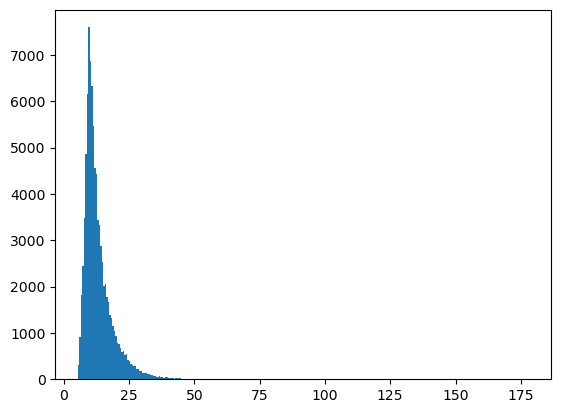

In [26]:
# Get the histogram distribution
plt.hist(M31_Pixels.flat, bins=300)
plt.show()

### 1) Intensity Normalization Or Linear Scaling Or Min Max Scaling

<img src='https://playfairdata.com/wp-content/uploads/2022/05/6.-minmax-calc.png' width=25%>

In [27]:
# A Common Function that will be used to plot the scaled pixel arrays
def plot_pixels(pixel_array, title, color):
  plt.imshow(pixel_array, cmap='gray', origin='lower')
  plt.title(title, color=color, weight='bold')
  plt.axis('off')

In [28]:
def compare_pixels(scaled_array, title):
  plt.subplot(1, 2, 1)
  plot_pixels(M31_Pixels, title='Original Image', color='black')
  plt.subplot(1, 2, 2)
  plot_pixels(scaled_array, title=title, color='royalblue')
  plt.tight_layout()
  plt.show()

In [29]:
# Define a function to normalize
def minmax_scaling(pixel_array):
  num = pixel_array - np.min(pixel_array)
  den = np.max(pixel_array) - np.min(pixel_array)
  return num/den

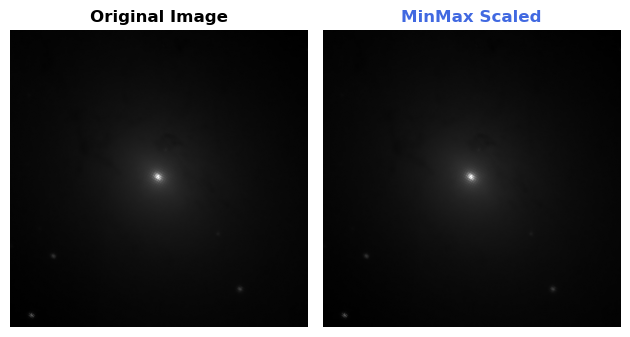

In [30]:
# Normalize the M31 data and visualize it!
minmax_array = minmax_scaling(M31_Pixels)
compare_pixels(minmax_array, title='MinMax Scaled')

### 2) Standardization Or Z scaling

<img src='https://tse2.mm.bing.net/th?id=OIP.aU-q_bfzwe1ObWyaU3CReQAAAA&pid=Api&P=0&h=180' width=15%>

In [32]:
# A function to standardize
def zscale(pixel_array):
  num = pixel_array - np.mean(pixel_array)
  den = np.std(pixel_array)
  return num/den

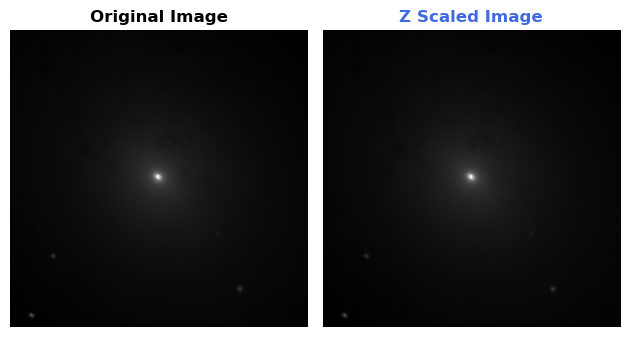

In [33]:
# Visualize the standardized M31 data
zscaled_array = zscale(M31_Pixels)
compare_pixels(zscaled_array, title='Z Scaled Image')

### 3) Log Normalization